In [39]:
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy as sc
import importlib
import collision
importlib.reload(collision)
from collision import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights

# parameters
e_mass = 5.48579909e-4    # electron mass in amu
t0 = 315775               # a.u. to K
tau0 = 2.418884326509e-17 # a.u. to sec

In [40]:
# define properties of molecules
reduced_masses = {"NaKNaK" : 62 / 2, "RbKRb" : 87 * (87 + 40) / (87 + 87 + 40)}     # amu
van_der_wall_coeffs = {"NaKNaK" : 561070, "RbKRb" : 8000}      # a.u.

molecules = "NaKNaK"
mu = reduced_masses[molecules] / e_mass      # now in a.u.
c6 = van_der_wall_coeffs[molecules]          # a.u.

# define natural units
beta = (2 * mu * c6) ** (1/4)    # length 
E_beta = 1 / (2 * mu * beta ** 2)   # energy
tau_beta = 2 * np.pi / E_beta    # time
print("reduced mass", mu)
print("C6", c6)
print("beta (a0)", beta)
print("E_beta (K)", E_beta * t0)
print("tau_beta (s)", tau_beta * tau0)

reduced mass 56509.54307916515
C6 561070
beta (a0) 501.8133487679625
E_beta (K) 1.1095363445288911e-05
tau_beta (s) 4.325448841671024e-06


In [21]:
num_samples = 500

# properties of resonant spectrum
mean_spacing = 10.0
mean_x = 0.1
num_resonances = 400       # should be odd
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

# thermal properties
threshold_energy = 0.1
temp = 0.5
num_energies = 2000

C:\Users\kevin\AppData\Local\Temp\ipykernel_44304\173395770.py:5: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  time_delay = sc.integrate.quad(f, 0, 10 * temp)[0]
C:\Users\kevin\AppData\Local\Temp\ipykernel_44304\173395770.py:5: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  time_delay = sc.integrate.quad(f, 0, 10 * temp)[0]


Fraction Positive:  0.1956


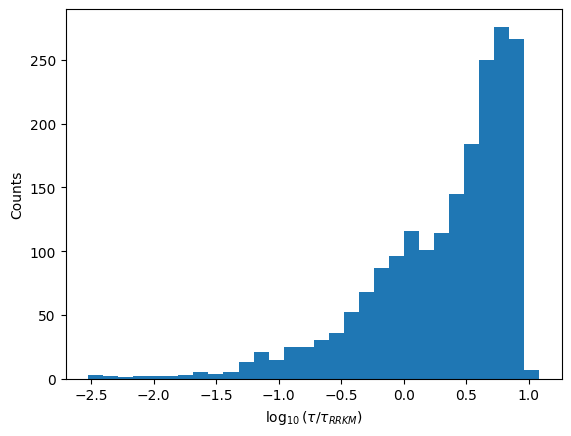

In [18]:
time_delays = []
for i in range(10000):
    energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
    f = lambda energy : relative_MB_weights(temp, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat, np.square(W_mat))
    time_delay = sc.integrate.quad(f, 0, 10 * temp)[0]
    time_delays.append(time_delay)

positive = [delay for delay in time_delays if delay > 0]
frac_positive = len(positive) / len(time_delays) 
print("Fraction Positive: ", frac_positive)

normalized = (mean_spacing / 2 / np.pi) * np.array(positive)
mean_delay = np.mean(normalized)
std_delay = np.std(normalized)

log_delay = np.log10(normalized)
plt.hist(log_delay, bins=30)
plt.xlabel(f"$\\log_{{10}} (\\tau / \\tau_{{RRKM}})$")
plt.ylabel("Counts")
plt.show()


C:\Users\kevin\AppData\Local\Temp\ipykernel_44304\1512995715.py:6: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  if (mean_spacing / 2 / np.pi) * sc.integrate.quad(f, 0, 10 * temp)[0] > 1:
C:\Users\kevin\AppData\Local\Temp\ipykernel_44304\1512995715.py:6: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  if (mean_spacing / 2 / np.pi) * sc.integrate.quad(f, 0, 10 * temp)[0] > 1:
c:\Users\kevin\OneDrive\PhD\stickycollisions\collision.py:104: RuntimeWarning: divide by zero encountered in scalar divide
  beta = 1 / temp
c:\Users\kevin\OneDrive\PhD\stickyco

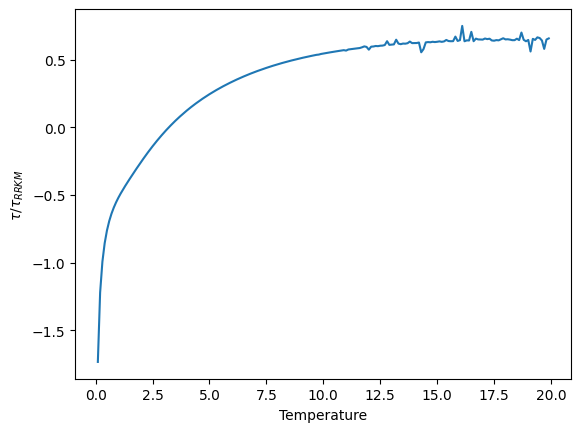

In [9]:
time_delays = []
temps = np.arange(0, 20, 0.1)
while True:
    energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
    f = lambda energy : relative_MB_weights(temp, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat, np.square(W_mat))
    if (mean_spacing / 2 / np.pi) * sc.integrate.quad(f, 0, 10 * temp)[0] > 1:
        break
for temp in temps:
    time_delay = sc.integrate.quad(f, 0, 10 * temp)[0]
    time_delays.append(time_delay)

normalized = (mean_spacing / 2 / np.pi) * np.array(time_delays)
mean_delay = np.mean(normalized)
std_delay = np.std(normalized)

plt.plot(temps, time_delays)
plt.ylabel(f"$\\tau / \\tau_{{RRKM}}$")
plt.xlabel("Temperature")
plt.show()


In [ ]:
for num_res in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:    
    time_delays = []
    for i in range(5000):
        energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_res, mean_spacing, mean_coupling_strength)
        f = lambda energy : relative_MB_weights(temp, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat, np.square(W_mat))
        time_delay = sc.integrate.quad(f, 0, 10 * temp)[0]
        time_delays.append(time_delay)

    positive = [delay for delay in time_delays if delay > 0]
    frac_positive = len(positive) / len(time_delays) 
    print("Fraction Positive: ", frac_positive)

    normalized = (mean_spacing / 2 / np.pi) * np.array(positive)
    mean_delay = np.mean(normalized)
    std_delay = np.std(normalized)

    log_delay = np.log10(normalized)
    plt.hist(log_delay, bins=30)
    plt.xlabel(f"$\\log_{{10}} (\\tau / \\tau_{{RRKM}})$")
    plt.ylabel("Counts")
    plt.title(f"d={mean_spacing}, x={mean_x}, N={num_res}, Fraction={frac_positive}")
    plt.savefig(f"Figures/resonances_{num_res}.pdf")
    plt.show()

C:\Users\kevin\AppData\Local\Temp\ipykernel_16844\469443657.py:9: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  time_delay = sc.integrate.quad(f, 0, temp)[0]
C:\Users\kevin\AppData\Local\Temp\ipykernel_16844\469443657.py:9: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  time_delay = sc.integrate.quad(f, 0, temp)[0]


Fraction Positive:  1.0


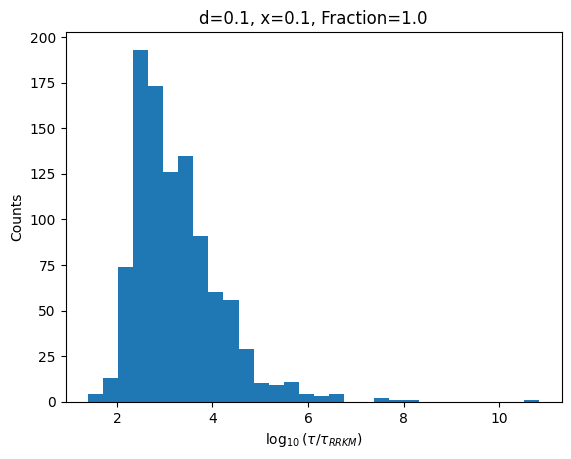

Fraction Positive:  1.0


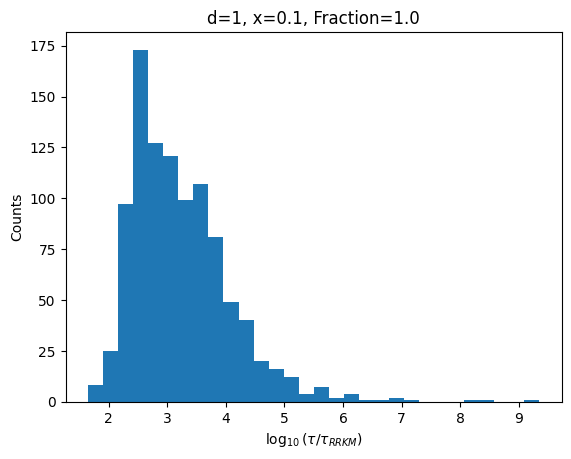

Fraction Positive:  1.0


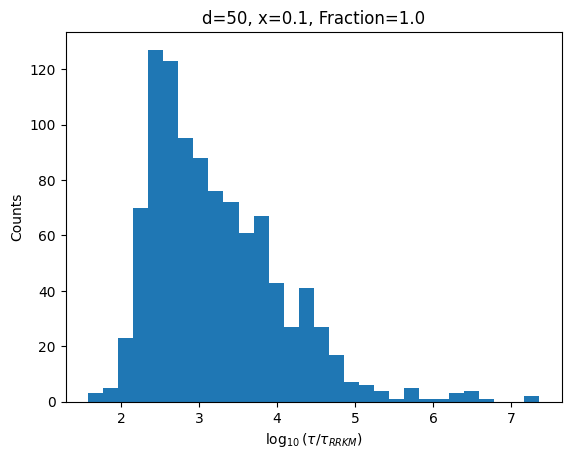

In [63]:
x = 0.1
for mean_spac in [0.1, 1, 50]:
    temp = 100 * mean_spac
    mean_coupling = np.sqrt(x * mean_spac / np.pi ** 2) 
    time_delays = []
    for i in range(1000):
        energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spac, mean_coupling)
        f = lambda energy : relative_MB_weights(temp, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat, np.square(W_mat), mean_spac * 10)
        time_delay = sc.integrate.quad(f, 0, temp)[0]
        time_delays.append(time_delay)

    positive = [delay for delay in time_delays if delay > 0]
    frac_positive = len(positive) / len(time_delays) 
    print("Fraction Positive: ", frac_positive)

    normalized = (1 / 2 / np.pi) * np.array(positive)
    mean_delay = np.mean(normalized)
    std_delay = np.std(normalized)

    log_delay = normalized
    plt.hist(log_delay, bins=30)
    plt.xlabel(f"$\\log_{{10}} (\\tau / \\tau_{{RRKM}})$")
    plt.ylabel("Counts")
    plt.title(f"d={mean_spac}, x={x}, Fraction={frac_positive}")
    # plt.savefig(f"Figures/d_{mean_spac}_x_{x}.pdf")
    plt.show()

In [51]:
for mean_spac in [0.1, 1, 50]:
    mean_coupling = np.sqrt(x * mean_spac / np.pi ** 2) 
    energy_GOE_mat, W_mat, x_actual = generate_spectrum(10000, mean_spac, mean_coupling)
    print(np.mean(energy_GOE_mat) / mean_spac, np.mean(np.square(W_mat)) / mean_spac)

-15.716442669180454 0.01013466950894749
4.696036427770741 0.010054195169051289
-11.169304436950206 0.010048951377639457


In [ ]:
energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spac, mean_coupling)

multiplier = 2
temp = 100

f = lambda energy : relative_MB_weights(temp, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat, np.square(W_mat))
g = lambda energy : relative_MB_weights(temp * multiplier, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat * multiplier, np.square(W_mat) * multiplier)


testf = sc.integrate.quad(f, 0, 10 * temp)[0]
testg = sc.integrate.quad(g, 0, 10 * temp * multiplier)[0]
print(testf, testg)

energy_grid_1 = np.linspace(0, 10 * temp, 20000)[1:]
spacing_1 = energy_grid_1[1] - energy_grid_1[0]
energy_grid_2 = np.linspace(0, 10 * temp * multiplier, 20000)[1:]
spacing_2 = energy_grid_2[1] - energy_grid_2[0]
test1 = spacing_1 * np.sum(relative_MB_weights(temp, energy_grid_1) * wigner_smith_matrix(energy_grid_1, energy_GOE_mat, np.square(W_mat)))
test2 = spacing_2 * np.sum(relative_MB_weights(temp, energy_grid_2 / multiplier) * wigner_smith_matrix(energy_grid_2, energy_GOE_mat * multiplier, np.square(W_mat) * multiplier))
print(test1, test2)

In [13]:
multiplier = 1
spacing = 5e-4
energy_grid_1 = np.arange(0, 10 * temp, spacing)[1:]
print(energy_grid_1[:10])
print(energy_grid_1.size)
test1 = spacing * np.sum(relative_MB_weights(temp, energy_grid_1) * wigner_smith_matrix(energy_grid_1, energy_GOE_mat * multiplier, np.square(W_mat) * multiplier))

f = lambda energy : relative_MB_weights(temp * multiplier, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat * multiplier, np.square(W_mat) * multiplier)
testf = sc.integrate.quad(f, 0, 10 * temp * multiplier)[0]

print(test1, testf)

[0.0005 0.001  0.0015 0.002  0.0025 0.003  0.0035 0.004  0.0045 0.005 ]
1999999
4.4947490526788725 2.8572003809695


C:\Users\kevin\AppData\Local\Temp\ipykernel_16844\3874504398.py:9: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  testf = sc.integrate.quad(f, 0, 10 * temp * multiplier)[0]


In [59]:
abar = (np.pi * 2 ** (-3/2) / math.gamma(5/4) / math.gamma(1/2)) ** 2
def wigner_smith_matrix_single(collision_energy, H_goe, W_squared, multiplier):
    # values for calculation
    k = np.sqrt(collision_energy / multiplier)
    A_mqdt = abar * k
    A_prime = abar / 2 / k
    G_mqdt = (1 / 3 - abar ** 2) * np.square(k)
    G_prime = (1 / 3 - abar ** 2)
    eta_mqdt = -abar * k
    eta_prime = -abar / 2 / k 

    energy_diff = collision_energy - H_goe
    ratio = W_squared / energy_diff

    Y_mat = -np.pi * np.sum(ratio)
    Y_prime = np.pi * np.sum(ratio / energy_diff) * multiplier

    K_mat = A_mqdt * Y_mat / (1 + G_mqdt * Y_mat)
    K_prime = (A_prime * Y_mat + A_mqdt * Y_prime) / (1 + G_mqdt * Y_mat) - A_mqdt * Y_mat * (G_prime * Y_mat + G_mqdt * Y_prime) / (1 + G_mqdt * Y_mat) ** 2
    # print(K_mat, K_prime)

    Q_mat = 2 * (eta_prime + K_prime / (1 + K_mat ** 2))
    
    return Q_mat

multiplier = 10
test1 = wigner_smith_matrix_single(1, energy_GOE_mat, np.square(W_mat), multiplier=1)
test2 = wigner_smith_matrix_single(multiplier, energy_GOE_mat * multiplier, np.square(W_mat) * multiplier, multiplier=multiplier)
print(test1, test2)

multiplier = 1000
temp = 100

f = lambda energy : relative_MB_weights(temp, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat, np.square(W_mat), 1)
g = lambda energy : relative_MB_weights(temp * multiplier, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat * multiplier, np.square(W_mat) * multiplier, multiplier)

testf = sc.integrate.quad(f, 0, 10 * temp)[0]
testg = sc.integrate.quad(g, 0, 10 * temp * multiplier)[0]
print(testf, testg, testg / testf)

-0.4413085360787 -0.4413085360787
0.06323201547511607 0.06323201547511541 0.9999999999999895


C:\Users\kevin\AppData\Local\Temp\ipykernel_16844\1169802466.py:37: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  testf = sc.integrate.quad(f, 0, 10 * temp)[0]
C:\Users\kevin\AppData\Local\Temp\ipykernel_16844\1169802466.py:38: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and 

In [ ]:
for mean_spac in [0.1, 0.5, 1, 5, 10, 50]:
    for x in [0.01, 0.05, 0.1, 0.5, 1, 5, 10]:
        mean_coupling = np.sqrt(x * mean_spac / np.pi ** 2)
        time_delays = []
        for i in range(5000):
            energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spac, mean_coupling)
            f = lambda energy : relative_MB_weights(temp, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat, np.square(W_mat))
            time_delay = sc.integrate.quad(f, 0, 10 * temp)[0]
            time_delays.append(time_delay)

        positive = [delay for delay in time_delays if delay > 0]
        frac_positive = len(positive) / len(time_delays) 
        print("Fraction Positive: ", frac_positive)

        normalized = (mean_spac / 2 / np.pi) * np.array(positive)
        mean_delay = np.mean(normalized)
        std_delay = np.std(normalized)

        log_delay = np.log10(normalized)
        plt.hist(log_delay, bins=30)
        plt.xlabel(f"$\\log_{{10}} (\\tau / \\tau_{{RRKM}})$")
        plt.ylabel("Counts")
        plt.title(f"d={mean_spac}, x={x}, Fraction={frac_positive}")
        plt.savefig(f"Figures/d_{mean_spac}_x_{x}.pdf")
        plt.show()

In [41]:
import pickle
import warnings

xs = np.round(np.pow(10, np.arange(-3, 3, 0.2)), 3)
spacings = np.round(np.pow(10, np.arange(-3, 0, 0.2)), 3)
temp = 1

all_data = []
import warnings
warnings.filterwarnings('ignore')
counter = 0

for mean_x in xs:
    for mean_spacing in spacings:
        mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)
        # if mean_x in done_coupling or mean_spacing in done_spacing:
        #     continue

        time_delays = []
        for i in range(1000):
            energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
            time_delay = thermal_time_delay(temp, energy_GOE_mat, W_mat, num_energies=100000)
            time_delays.append(time_delay)

        positive = [delay for delay in time_delays if delay > 0]
        frac_positive = len(positive) / len(time_delays) 

        normalized = (mean_spacing / 2 / np.pi) * np.array(positive)
        
        absolute_delay = np.mean(positive)

        mean_delay = np.mean(normalized)
        std_delay = np.std(normalized)

        pkl_dict = {"delay" : time_delays, "positive" : frac_positive, "mean" : mean_delay, "std" : std_delay, "mean_spacing" : mean_spacing, "mean_x" : mean_x, "absolute_delay" : absolute_delay}
        all_data.append(pkl_dict)

        with open(f'Sweep/data_fine_{counter}.pkl', 'wb') as f:
            pickle.dump(all_data, f)
        counter += 1

In [37]:
xs = np.round(np.pow(10, np.arange(-3, 3, 0.2)), 3)
spacings = np.round(np.pow(10, np.arange(-3, 3, 0.2)), 3)
print(xs)

with open(f'Sweep/data_old.pkl', 'rb') as f:
    data = pickle.load(f)
done_spacing = [point["mean_spacing"] for point in data]
done_coupling = [point["mean_x"] for point in data]
print(done_spacing)
print(done_coupling)

for mean_x in xs:
    for mean_spacing in spacings:
        if mean_x in done_coupling or mean_spacing in done_spacing:
            continue
        print(mean_x, mean_spacing)


[1.00000e-03 2.00000e-03 3.00000e-03 4.00000e-03 6.00000e-03 1.00000e-02
 1.60000e-02 2.50000e-02 4.00000e-02 6.30000e-02 1.00000e-01 1.58000e-01
 2.51000e-01 3.98000e-01 6.31000e-01 1.00000e+00 1.58500e+00 2.51200e+00
 3.98100e+00 6.31000e+00 1.00000e+01 1.58490e+01 2.51190e+01 3.98110e+01
 6.30960e+01 1.00000e+02 1.58489e+02 2.51189e+02 3.98107e+02 6.30957e+02]
[np.float64(0.001), np.float64(0.003), np.float64(0.01), np.float64(0.032), np.float64(0.1), np.float64(0.316), np.float64(1.0), np.float64(3.162), np.float64(10.0), np.float64(31.623), np.float64(100.0), np.float64(316.228), np.float64(0.001), np.float64(0.003), np.float64(0.01), np.float64(0.032), np.float64(0.1), np.float64(0.316), np.float64(1.0), np.float64(3.162), np.float64(10.0), np.float64(31.623), np.float64(100.0), np.float64(316.228), np.float64(0.001), np.float64(0.003), np.float64(0.01), np.float64(0.032), np.float64(0.1), np.float64(0.316), np.float64(1.0), np.float64(3.162), np.float64(10.0), np.float64(31.623)